Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
print(df.shape)
print(df.head())
print(df['label'].value_counts())

(5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64


Text Preprocessing

In [3]:
df['text'] = df['text'].str.lower()
df['text'] = df['text'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
df['text'] = df['text'].str.strip()
print(df['text'].head())

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: text, dtype: str


Encode Labels

In [4]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


Split Data

In [5]:
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 4457, Test: 1115


CountVectorizer (text to word freq vectors)

In [6]:
count_vectorizer = CountVectorizer(max_features=2000, stop_words='english')
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)
print(X_train_count.shape)

(4457, 2000)


TF-IDF Vectorizer (checks importance also)

In [7]:
tfidf_vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print(X_train_tfidf.shape)

(4457, 2000)


Train Model with CountVectorizer

In [8]:
model_count = MultinomialNB()
model_count.fit(X_train_count, y_train)
y_pred_count = model_count.predict(X_test_count)
print("CountVectorizer Accuracy:", accuracy_score(y_test, y_pred_count))
print(confusion_matrix(y_test, y_pred_count))

CountVectorizer Accuracy: 0.97847533632287
[[959   6]
 [ 18 132]]


Train Model with TF-IDF Vectorizer

In [9]:
model_tfidf = MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print(confusion_matrix(y_test, y_pred_tfidf))

TF-IDF Accuracy: 0.9739910313901345
[[965   0]
 [ 29 121]]


Compare Results

In [10]:
print("Comparison")
print("CountVectorizer Accuracy:", accuracy_score(y_test, y_pred_count))
print("TF-IDF Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("\nCountVectorizer Classification Report:")
print(classification_report(y_test, y_pred_count))
print("\nTF-IDF Classification Report:")
print(classification_report(y_test, y_pred_tfidf))

Comparison
CountVectorizer Accuracy: 0.97847533632287
TF-IDF Accuracy: 0.9739910313901345

CountVectorizer Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.96      0.88      0.92       150

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115


TF-IDF Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.89       150

    accuracy                           0.97      1115
   macro avg       0.99      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



Feature Importance Visualization

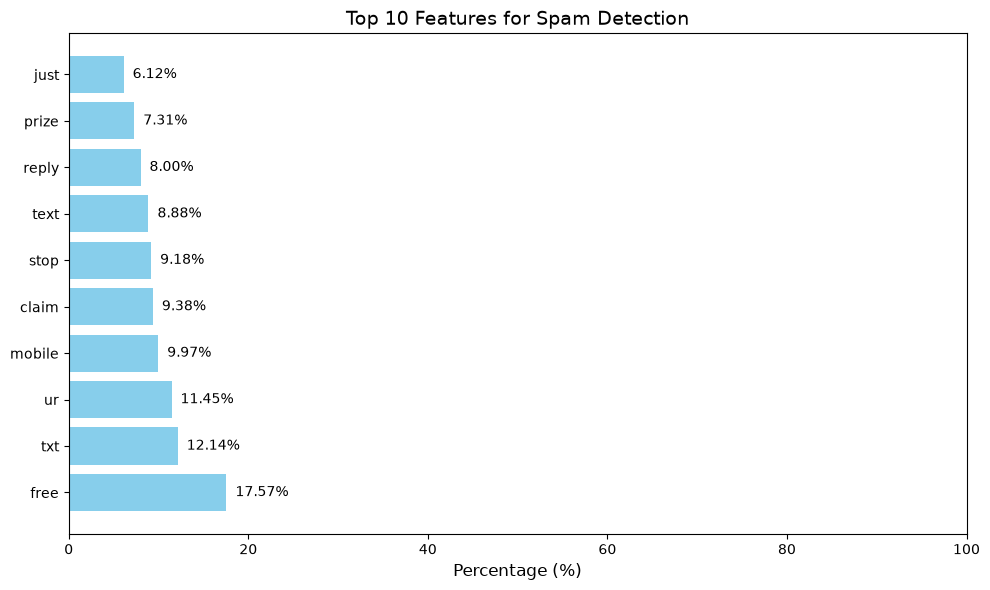

In [11]:
feature_names = count_vectorizer.get_feature_names_out()
top_features = model_count.feature_log_prob_[1].argsort()[-10:][::-1]

top_words = [feature_names[i] for i in top_features]
top_probs = [np.exp(model_count.feature_log_prob_[1][i]) for i in top_features]

total = sum(top_probs)
top_percentages = [(p / total) * 100 for p in top_probs]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_words, top_percentages, color='skyblue')
plt.xlabel('Percentage (%)', fontsize=12)
plt.title('Top 10 Features for Spam Detection', fontsize=14)
plt.xlim(0, 100)

for bar, pct in zip(bars, top_percentages):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{pct:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()